In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine
import matplotlib.ticker as ticker

In [2]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

try:
    print("Conectando a PostgreSQL...")
    db_url = f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
    engine = create_engine(db_url)
    fact_ventas = pd.read_sql('SELECT * FROM fact_ventas ORDER BY "ID_Venta" ASC', engine)
    dim_producto = pd.read_sql('SELECT * FROM dim_producto', engine)
    dim_cliente = pd.read_sql('SELECT * FROM dim_cliente', engine)
    print("Datos cargados desde SQL (Ordenados).")
except Exception as e:
    print(f"Error SQL ({e}). Cargando desde CSV...")
    fact_ventas = pd.read_csv('fact_ventas.csv')
    dim_producto = pd.read_csv('dim_producto.csv')
    dim_cliente = pd.read_csv('dim_cliente.csv')

df = fact_ventas.merge(dim_producto, on='ID_Producto', how='left')
df = df.merge(dim_cliente, on='ID_Cliente', how='left')
df = df.sort_values(by='ID_Venta', ascending=True)

df = df.reset_index(drop=True)
df['Fecha'] = pd.to_datetime(df['Fecha'])
df['Mes'] = df['Fecha'].dt.strftime('%Y-%m')
df['Año'] = df['Fecha'].dt.year

display(df[['ID_Venta', 'Fecha', 'Producto', 'Venta_Total']].head(5))


Conectando a PostgreSQL...
Datos cargados desde SQL (Ordenados).


,ID_Venta,Fecha,Producto,Venta_Total
0,1,2025-10-30,Arepa,5889.60
1,2,2025-11-17,Arepa,13809.95
2,3,2025-10-22,Leche,25488.00
3,4,2025-10-20,Cereal,9367.95
4,5,2025-10-20,Leche,6828.00


## Metricas de Estadisticas Descriptivas

In [5]:
cols_stats = ['Cantidad', 'Precio_Unitario', 'Descuento', 'Costo_Envio', 'Venta_Total']

desc = df[cols_stats].describe().T

pd.options.display.float_format= '{:,.2f}'.format

metricas = desc[['mean', '50%', 'std', 'min', 'max']]
metricas.columns = ['Media (Promedio)', 'Mediana', 'Desviacion Estandar', 'Minimo', 'Maximo']

display(metricas)

ticket_promedio = metricas.loc['Venta_Total', 'Media (Promedio)']
print(f"1. El ticket promedio de venta es de {ticket_promedio:,.2f}")

,Media (Promedio),Mediana,Desviacion Estandar,Minimo,Maximo
Cantidad,5.65,6.00,9.57,1.00,"7,500.00"
Precio_Unitario,"3,085.97","2,998.00","5,930.18","-35,205.24","4,958,750.00"
Descuento,0.10,0.10,0.07,0.00,1.00
Costo_Envio,"2,565.59",0.00,"5,803.32",0.00,"500,000.00"
Venta_Total,"18,243.45","15,443.20","36,605.50",800.80,"18,249,974.00"


1. El ticket promedio de venta es de 18,243.45


## Distribuccion de ventas por mes 

C:\Users\rober\AppData\Local\Temp\ipykernel_21732\3768323778.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['${:,.0f}M'.format(x/1000000) for x in current_values])


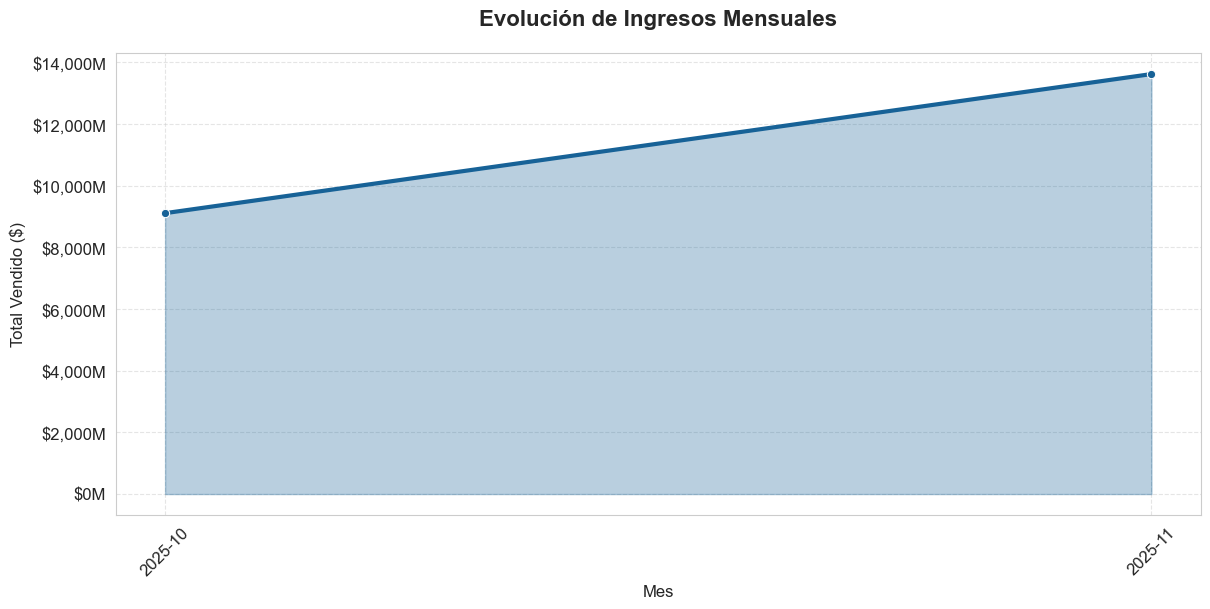

In [7]:
ventas_tiempo = df.groupby('Mes')['Venta_Total'].sum().reset_index()

plt.figure(figsize=(14,6))

sns.lineplot(data=ventas_tiempo, x="Mes", y="Venta_Total", marker='o', linewidth=3, color="#176297")
plt.fill_between(ventas_tiempo['Mes'], ventas_tiempo['Venta_Total'], alpha=0.3, color='#176297')

plt.title('Evolución de Ingresos Mensuales', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Total Vendido ($)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)

current_values = plt.gca().get_yticks()
plt.gca().set_yticklabels(['${:,.0f}M'.format(x/1000000) for x in current_values])

plt.show()


## Top 5 más vendidos

C:\Users\rober\AppData\Local\Temp\ipykernel_21732\4091870788.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top_prod, y='Producto', x='Venta_Total', palette='viridis')


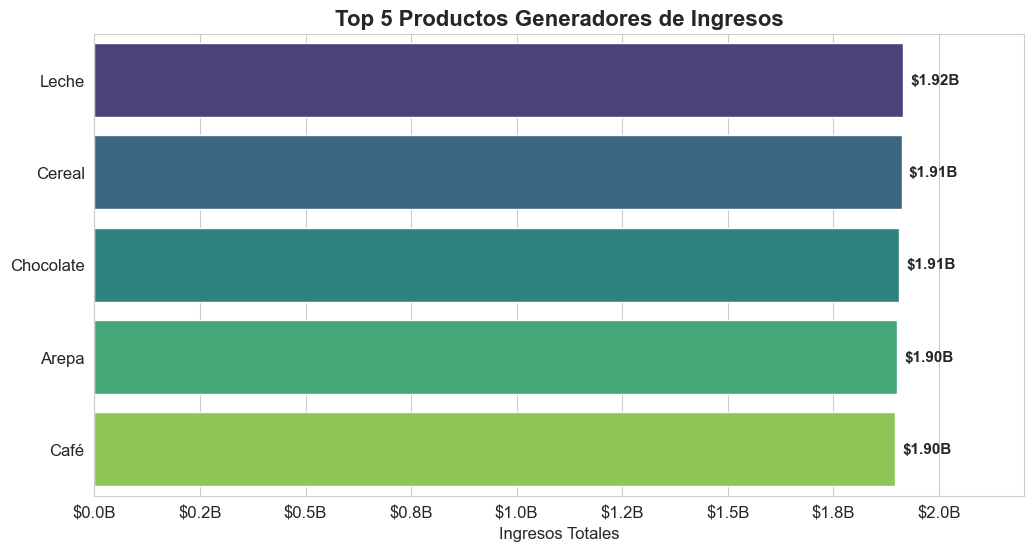

💡 INSIGHT: El producto 'Leche' lidera con ventas superiores a $1.92 Billones.


In [ ]:
import matplotlib.ticker as ticker
top_prod = df.groupby('Producto')['Venta_Total'].sum().sort_values(ascending=False).head(5).reset_index()
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=top_prod, y='Producto', x='Venta_Total', palette='viridis')

plt.title('Top 5 Productos Generadores de Ingresos', fontsize=16, fontweight='bold')
plt.ylabel('') 
plt.xlabel('Ingresos Totales', fontsize=12)

def formatear_billones(x, pos):
    return '${:,.1f}B'.format(x * 1e-9)

ax.xaxis.set_major_formatter(ticker.FuncFormatter(formatear_billones))


for i in ax.containers:
    labels = [f'${v * 1e-9:.2f}B' for v in i.datavalues]
    ax.bar_label(i, labels=labels, padding=5, fontsize=11, fontweight='bold')

plt.xlim(right=top_prod['Venta_Total'].max() * 1.15) 
plt.show()
producto_top = top_prod.iloc[0]['Producto']
print(f"INSIGHT: El producto '{producto_top}' lidera con ventas superiores a ${top_prod.iloc[0]['Venta_Total']/1e9:.2f} Billones.")

## Box- Plot

C:\Users\rober\AppData\Local\Temp\ipykernel_21732\1694687158.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Tipo_Producto', y='Venta_Total', palette='Set2')


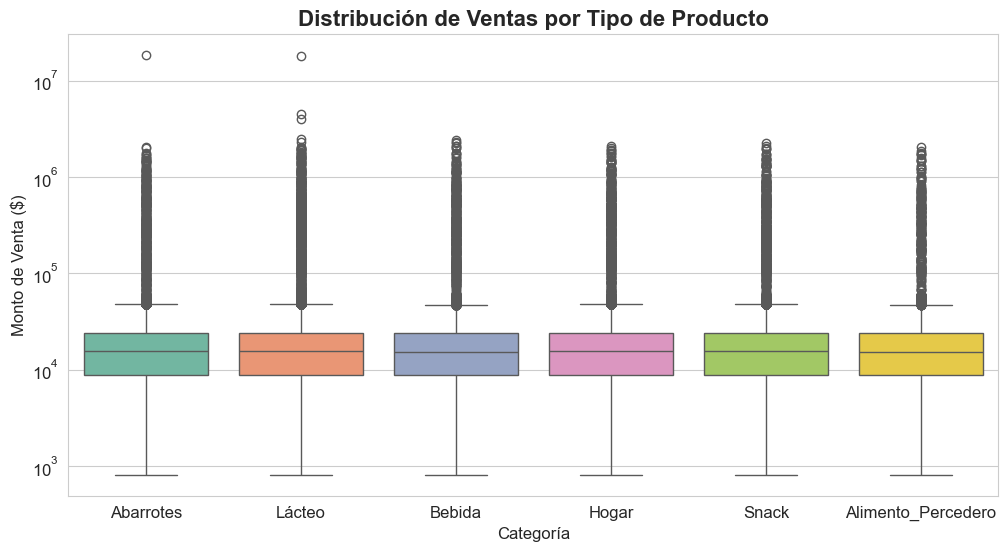

- La línea dentro de la caja es la MEDIANA.
- Los puntos fuera de los 'bigotes' son VENTAS ATÍPICAS (Outliers).
- Si una caja es más alta que otra, esa categoría tiene mayor variabilidad en sus precios.


In [ ]:
plt.figure(figsize=(12, 6))

sns.boxplot(data=df, x='Tipo_Producto', y='Venta_Total', palette='Set2')
plt.title('Distribución de Ventas por Tipo de Producto', fontsize=16, fontweight='bold')
plt.xlabel('Categoría', fontsize=12)
plt.ylabel('Monto de Venta ($)', fontsize=12)
plt.yscale('log')
plt.show()
print("- La línea dentro de la caja es la MEDIANA.")
print("- Los puntos fuera de los 'bigotes' son VENTAS ATÍPICAS (Outliers).")
print("- Si una caja es más alta que otra, esa categoría tiene mayor variabilidad en sus precios.")



In [16]:

ballenas = df[df['Venta_Total'] > 5000000].sort_values(by='Venta_Total', ascending=False)
print(f"Se detectaron {len(ballenas)} ventas gigantes.")
print("\nEjemplo de las 5 ventas más grandes:")
display(ballenas[['Fecha', 'ID_Venta', 'Tipo_Cliente', 'Producto', 'Venta_Total','Origen_Dato']].head())
print("\n¿Quiénes compran esto?")
print(ballenas['Tipo_Cliente'].value_counts())

Se detectaron 2 ventas gigantes.

Ejemplo de las 5 ventas más grandes:


,Fecha,ID_Venta,Tipo_Cliente,Producto,Venta_Total,Origen_Dato
892580,2025-10-23,892581,Mayorista,Arepa,"18,249,974.00",Original
25709,2025-10-30,25710,Gobierno,Cereal,"17,898,000.00",Original



¿Quiénes compran esto?
Tipo_Cliente
Mayorista    1
Gobierno     1
Name: count, dtype: int64
